# Exhaustive feature subset search - ExtraTrees
**Stage 1** : all subsets k=2..7 from 7 candidate features × 4 HP configs  
**Stage 2** : Optuna fine-tuning on top-5 subsets


In [3]:
!pip install optuna -q

In [21]:
import os, time, warnings
from itertools import chain, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import ast
import matplotlib.patches as mpatches


optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


## Configuration

In [8]:
ON_KAGGLE = os.path.exists("/kaggle")

DATA_DIR = (
    "/kaggle/input/datasets/bolesawpaliwoda/aml-project-2/data"
    if ON_KAGGLE else "../data"
)
from pathlib import Path
DATA_DIR = Path(DATA_DIR)

TRAIN_X = DATA_DIR / "processed" / "x_train_scaled_reduced_after_mi.csv"
TRAIN_Y = DATA_DIR / "y_train.txt"

CANDIDATES = ["V176", "V255", "V191", "V160", "V215", "V380", "V342"]

CV_FOLDS     = 5
RANDOM_STATE = 0          # Stage-1 single-seed screen + Optuna sampler seed
CAP          = 1000

FIXED_HP_CONFIGS = [
    dict(n_estimators=419, max_depth=6,  min_samples_split=7, min_samples_leaf=2,  criterion="gini",    class_weight="balanced"),
    dict(n_estimators=267, max_depth=5,  min_samples_split=6, min_samples_leaf=1,  criterion="entropy", class_weight=None),
    dict(n_estimators=158, max_depth=3,  min_samples_split=7, min_samples_leaf=3,  criterion="gini",    class_weight=None),
    dict(n_estimators=54,  max_depth=3,  min_samples_split=5, min_samples_leaf=5,  criterion="entropy", class_weight="balanced"),
]

TOP_N_OPTUNA  = 8
OPTUNA_TRIALS = 80

OPTUNA_SEEDS = [0, 1, 2]

print(f"Environment : {'Kaggle' if ON_KAGGLE else 'local'}")
print(f"DATA_DIR    : {DATA_DIR}")
print(f"Candidates  : {CANDIDATES}")
print(f"Subsets k=2..7: {sum(1 for k in range(2,8) for _ in combinations(CANDIDATES,k))}")
print(f"Selection seeds (Optuna objective): {OPTUNA_SEEDS}")


Environment : local
DATA_DIR    : ..\data
Candidates  : ['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']
Subsets k=2..7: 120
Selection seeds (Optuna objective): [0, 1, 2]


## Helpers

In [9]:
def sweep_cutoff(y_true, p, n_vars, cap=CAP):
    order = np.argsort(-p)
    best_s, best_n = -np.inf, 0
    for n in range(1, min(cap, len(p)) + 1):
        idx = order[:n]
        tp  = int(np.sum(y_true[idx] == 1))
        s   = tp * 10 - (n - tp) * 5 - n_vars * 200
        if s > best_s:
            best_s, best_n = s, n
    if best_n == 0:
        return int(best_s), 0, 0.0, 0, 0
    tp_best  = int(np.sum(y_true[order[:best_n]] == 1))
    thr_best = float(p[order[best_n - 1]])
    return int(best_s), best_n, thr_best, tp_best, best_n - tp_best


def oof_score(X_arr, y, hp, n_vars, seed=RANDOM_STATE):
    """Single-seed OOF score (used by the Stage-1 coarse screen)."""
    model = ExtraTreesClassifier(**hp, random_state=seed, n_jobs=-1)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    p_oof = cross_val_predict(model, X_arr, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
    return sweep_cutoff(y, p_oof, n_vars)


def oof_score_multiseed(X_arr, y, hp, n_vars, seeds=OPTUNA_SEEDS):
    """Mean OOF score across CV seeds - the honest objective for HP selection.

    Both the fold split and the ExtraTrees randomness vary together per seed,
    matching the stability protocol in notebook 06.
    Returns (mean_score, std_score, per_seed_scores)."""
    scores = []
    for s in seeds:
        model = ExtraTreesClassifier(**hp, random_state=s, n_jobs=-1)
        skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=s)
        p     = cross_val_predict(model, X_arr, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
        scores.append(sweep_cutoff(y, p, n_vars)[0])
    return float(np.mean(scores)), float(np.std(scores)), scores


def all_subsets(elements, min_k=2, max_k=None):
    max_k = max_k or len(elements)
    return list(chain.from_iterable(combinations(elements, k) for k in range(min_k, max_k + 1)))


## Data

In [10]:
X_df = pd.read_csv(TRAIN_X)
y    = np.loadtxt(TRAIN_Y, skiprows=1).astype(int)
print(f"X_train {X_df.shape}   y positive rate {y.mean():.3f}")
assert all(c in X_df.columns for c in CANDIDATES), "Missing candidate columns!"


X_train (5000, 493)   y positive rate 0.498


## Stage 1 - exhaustive search

In [ ]:
subsets = all_subsets(CANDIDATES)
rows    = []
t0      = time.time()

for i, subset in enumerate(subsets):
    feats = list(subset)
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    best  = None

    for hp in FIXED_HP_CONFIGS:
        score, N, thr, tp, fp = oof_score(X_arr, y, hp, n_vars=k)
        if best is None or score > best["score"]:
            best = dict(score=score, k=k, N=N, thr=thr, tp=tp, fp=fp, features=feats, hp=hp)

    rows.append(best)
    eta = (time.time() - t0) / (i + 1) * (len(subsets) - i - 1)
    print(f"[{i+1:3d}/{len(subsets)}] k={k}  {feats}  score={best['score']}  N={best['N']}  TP={best['tp']}  ETA {eta/60:.1f}min")

results1 = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
print(f"\nStage 1 done: {(time.time()-t0)/60:.1f} min")


[  1/120] k=2  ['V176', 'V255']  score=4950  N=991  TP=687  ETA 29.8min
[  2/120] k=2  ['V176', 'V191']  score=4920  N=1000  TP=688  ETA 29.6min
[  3/120] k=2  ['V176', 'V160']  score=4845  N=1000  TP=683  ETA 29.3min
[  4/120] k=2  ['V176', 'V215']  score=4545  N=1000  TP=663  ETA 29.1min
[  5/120] k=2  ['V176', 'V380']  score=4925  N=999  TP=688  ETA 29.4min
[  6/120] k=2  ['V176', 'V342']  score=4730  N=999  TP=675  ETA 29.1min
[  7/120] k=2  ['V255', 'V191']  score=4710  N=1000  TP=674  ETA 29.2min
[  8/120] k=2  ['V255', 'V160']  score=4920  N=1000  TP=688  ETA 28.8min
[  9/120] k=2  ['V255', 'V215']  score=4815  N=1000  TP=681  ETA 28.5min
[ 10/120] k=2  ['V255', 'V380']  score=4905  N=1000  TP=687  ETA 28.2min
[ 11/120] k=2  ['V255', 'V342']  score=4715  N=999  TP=674  ETA 27.8min
[ 12/120] k=2  ['V191', 'V160']  score=4755  N=997  TP=676  ETA 27.4min
[ 13/120] k=2  ['V191', 'V215']  score=4635  N=1000  TP=669  ETA 27.3min
[ 14/120] k=2  ['V191', 'V380']  score=4770  N=997  TP=6

### Results

In [20]:
best_per_k = results1.groupby("k").first().reset_index()
best_per_k["var_cost"]   = best_per_k["k"] * 200
best_per_k["precision@N"] = (best_per_k["tp"] / best_per_k["N"]).round(3)
display(best_per_k[["k", "score", "N", "tp", "fp", "var_cost", "precision@N", "features"]]
        .style.highlight_max(subset=["score"], color="#c6efce"))


,k,score,N,tp,fp,var_cost,precision@N,features
0,2,4950,991,687,304,400,0.693000,"['V176', 'V255']"
1,3,5335,1000,729,271,600,0.729000,"['V176', 'V255', 'V342']"
2,4,5400,998,746,252,800,0.747000,"['V255', 'V160', 'V215', 'V380']"
3,5,5595,1000,773,227,1000,0.773000,"['V255', 'V191', 'V215', 'V380', 'V342']"
4,6,5580,999,785,214,1200,0.786000,"['V176', 'V255', 'V191', 'V160', 'V380', 'V342']"
5,7,5485,993,790,203,1400,0.796000,"['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']"


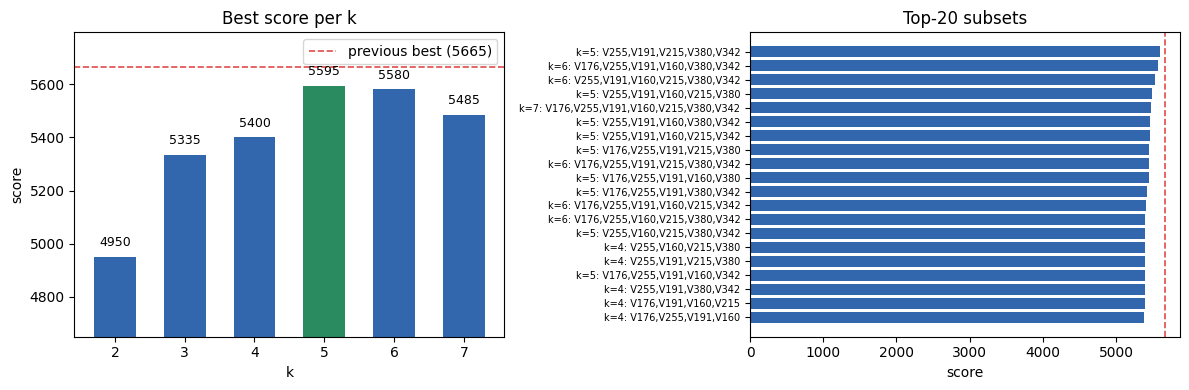

Global best (Stage 1): score=5595  k=5  features=['V255', 'V191', 'V215', 'V380', 'V342']


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

k_vals = best_per_k["k"].tolist()
scores = best_per_k["score"].tolist()
colors = ["#2a8a60" if s == max(scores) else "#3266ad" for s in scores]
ax1.bar(k_vals, scores, color=colors, width=0.6)
ax1.axhline(5665, color="#e24b4a", linestyle="--", lw=1.2, label="previous best (5665)")
ax1.set_xlabel("k"); ax1.set_ylabel("score"); ax1.set_title("Best score per k")
ax1.set_ylim(min(scores) - 300, max(scores) + 200); ax1.legend()
for k, s in zip(k_vals, scores):
    ax1.text(k, s + 40, str(s), ha="center", fontsize=9)

top20 = results1.head(20).copy()
top20["label"] = top20.apply(lambda r: f"k={r['k']}: {','.join(r['features'])}", axis=1)
yp = range(len(top20))
ax2.barh(list(yp), top20["score"].tolist(), color="#3266ad")
ax2.axvline(5665, color="#e24b4a", linestyle="--", lw=1.2)
ax2.set_yticks(list(yp)); ax2.set_yticklabels(top20["label"].tolist(), fontsize=7)
ax2.invert_yaxis(); ax2.set_xlabel("score"); ax2.set_title("Top-20 subsets")

plt.tight_layout(); plt.show()
print(f"Global best (Stage 1): score={results1.iloc[0]['score']}  k={results1.iloc[0]['k']}  features={results1.iloc[0]['features']}")


In [9]:
results1.to_csv("exhaustive_stage1.csv", index=False)
print("Saved exhaustive_stage1.csv")

Saved exhaustive_stage1.csv


## Stage 2 - Optuna HP fine-tuning

In [13]:
results1 = pd.read_csv("../results/features_subset_selection/exhaustive_stage1.csv")

In [15]:
optuna_rows = []
t0 = time.time()

import ast

for rank, (_, row) in enumerate(results1.head(TOP_N_OPTUNA).iterrows(), 1):
    feats = row["features"]
    
    if isinstance(feats, str):
        feats = ast.literal_eval(feats)
        
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()

    fixed_baseline = max(oof_score_multiseed(X_arr, y, hp, k)[0] for hp in FIXED_HP_CONFIGS)

    print(f"\n[{rank}/{TOP_N_OPTUNA}] k={k}  {feats}")
    print(f"   fixed-HP multiseed baseline = {fixed_baseline:.0f}   (stage1 seed0 = {row['score']})")

    def objective(trial):
        hp = dict(
            n_estimators      = trial.suggest_int("n_estimators", 50, 600),
            max_depth         = trial.suggest_int("max_depth", 2, 12),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 12),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 10),
            criterion         = trial.suggest_categorical("criterion", ["gini", "entropy"]),
            class_weight      = trial.suggest_categorical("class_weight", ["balanced", None]),
        )
        mean_s, _, _ = oof_score_multiseed(X_arr, y, hp, n_vars=k)
        return mean_s

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    for hp in FIXED_HP_CONFIGS:
        study.enqueue_trial({
            "n_estimators": hp["n_estimators"], "max_depth": hp["max_depth"] or 8,
            "min_samples_split": hp["min_samples_split"], "min_samples_leaf": hp["min_samples_leaf"],
            "criterion": hp["criterion"], "class_weight": hp["class_weight"],
        })
    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

    mean_s, std_s, per_seed = oof_score_multiseed(X_arr, y, study.best_params, n_vars=k)
    s0, N0, thr0, tp0, fp0 = oof_score(X_arr, y, study.best_params, n_vars=k)

    print(f"   -> Optuna multiseed: {mean_s:.0f} +/- {std_s:.0f}  "
          f"({mean_s - fixed_baseline:+.0f} vs fixed)   seed0: score={s0} N={N0} TP={tp0}")

    optuna_rows.append(dict(score=mean_s, std=std_s, per_seed=per_seed,
                            fixed_baseline=fixed_baseline, seed0_score=s0,
                            k=k, N=N0, thr=thr0, tp=tp0, fp=fp0,
                            features=feats, hp=study.best_params))

results2 = pd.DataFrame(optuna_rows).sort_values("score", ascending=False).reset_index(drop=True)
print(f"\nStage 2 done: {(time.time()-t0)/60:.1f} min")



[1/8] k=5  ['V255', 'V191', 'V215', 'V380', 'V342']
   fixed-HP multiseed baseline = 5490   (stage1 seed0 = 5595)


  0%|          | 0/80 [00:00<?, ?it/s]

   -> Optuna multiseed: 5517 +/- 59  (+27 vs fixed)   seed0: score=5600 N=999 TP=773

[2/8] k=6  ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']
   fixed-HP multiseed baseline = 5535   (stage1 seed0 = 5580)


  0%|          | 0/80 [00:00<?, ?it/s]

   -> Optuna multiseed: 5593 +/- 19  (+58 vs fixed)   seed0: score=5585 N=998 TP=785

[3/8] k=6  ['V255', 'V191', 'V160', 'V215', 'V380', 'V342']
   fixed-HP multiseed baseline = 5467   (stage1 seed0 = 5530)


...

   -> Optuna multiseed: 5563 +/- 31  (+97 vs fixed)   seed0: score=5520 N=1000 TP=768

[7/8] k=5  ['V255', 'V191', 'V160', 'V215', 'V342']
   fixed-HP multiseed baseline = 5337   (stage1 seed0 = 5460)


  0%|          | 0/80 [00:00<?, ?it/s]

   -> Optuna multiseed: 5350 +/- 35  (+13 vs fixed)   seed0: score=5400 N=1000 TP=760

[8/8] k=5  ['V176', 'V255', 'V191', 'V215', 'V380']
   fixed-HP multiseed baseline = 5378   (stage1 seed0 = 5445)


  0%|          | 0/80 [00:00<?, ?it/s]

   -> Optuna multiseed: 5405 +/- 86  (+27 vs fixed)   seed0: score=5505 N=1000 TP=767

Stage 2 done: 152.7 min


In [16]:
results2.to_csv("../results/exhaustive_stage2.csv", index=False)
print("Saved exhaustive_stage2.csv")

Saved exhaustive_stage2.csv


## Final results

In [17]:
# Stage-1 scores are single-seed (coarse screen) and are NOT comparable to the
# multi-seed Stage-2 means, so the final winner is taken from results2 only.
final = results2.copy()
best  = final.iloc[0]

print("=" * 56)
print("BEST RESULT  (multi-seed selection)")
print(f"  mean score : {best['score']:.0f} +/- {best['std']:.0f}   seeds={OPTUNA_SEEDS}")
print(f"  seed0 score: {best['seed0_score']}   (single representative split)")
print(f"  k          : {best['k']}   (var cost: {best['k']*200})")
print(f"  features   : {best['features']}")
print(f"  N/TP/FP@s0 : {best['N']} / {best['tp']} / {best['fp']}   prec@N {best['tp']/best['N']:.1%}")
print(f"  HP         : {best['hp']}")
print("=" * 56)

display(final[["score", "std", "seed0_score", "k", "N", "tp", "fp", "features"]]
        .assign(**{"prec@N": lambda d: (d.tp / d.N).map("{:.1%}".format)})
        .style.highlight_max(subset=["score"], color="#c6efce"))


BEST RESULT  (multi-seed selection)
  mean score : 5593 +/- 19   seeds=[0, 1, 2]
  seed0 score: 5585   (single representative split)
  k          : 6   (var cost: 1200)
  features   : ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']
  N/TP/FP@s0 : 998 / 785 / 213   prec@N 78.7%
  HP         : {'n_estimators': 526, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 6, 'criterion': 'gini', 'class_weight': None}


,score,std,seed0_score,k,N,tp,fp,features,prec@N
0,5593.333333,19.293062,5585,6,998,785,213,"['V176', 'V255', 'V191', 'V160', 'V380', 'V342']",78.7%
1,5570.000000,32.403703,5540,7,1000,796,204,"['V176', 'V255', 'V191', 'V160', 'V215', 'V380', 'V342']",79.6%
2,5563.333333,30.641294,5520,5,1000,768,232,"['V255', 'V191', 'V160', 'V380', 'V342']",76.8%
3,5543.333333,23.213980,5575,6,1000,785,215,"['V255', 'V191', 'V160', 'V215', 'V380', 'V342']",78.5%
4,5516.666667,58.925565,5600,5,999,773,226,"['V255', 'V191', 'V215', 'V380', 'V342']",77.4%
5,5501.666667,59.768070,5580,5,1000,772,228,"['V255', 'V191', 'V160', 'V215', 'V380']",77.2%
6,5405.000000,86.023253,5505,5,1000,767,233,"['V176', 'V255', 'V191', 'V215', 'V380']",76.7%
7,5350.000000,35.355339,5400,5,1000,760,240,"['V255', 'V191', 'V160', 'V215', 'V342']",76.0%


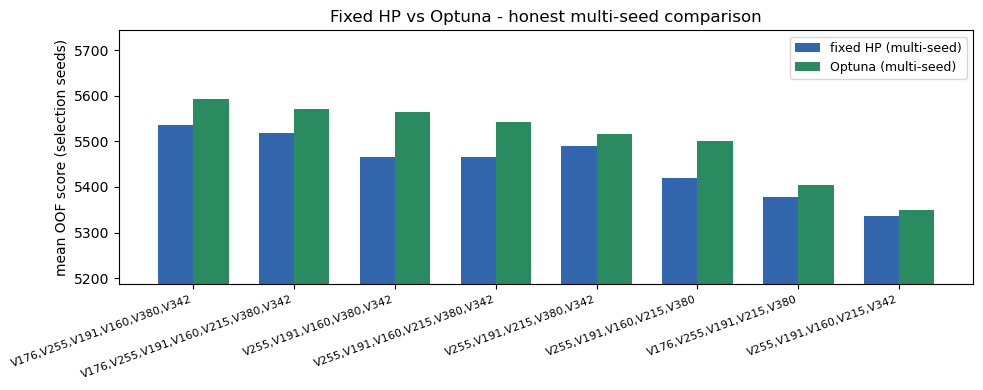

In [18]:
comp = results2.copy()
comp["label"] = comp["features"].apply(lambda f: ",".join(f))

x, w = range(len(comp)), 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([i - w/2 for i in x], comp["fixed_baseline"], width=w,
       label="fixed HP (multi-seed)", color="#3266ad")
ax.bar([i + w/2 for i in x], comp["score"], width=w,
       label="Optuna (multi-seed)", color="#2a8a60")
ax.set_xticks(list(x))
ax.set_xticklabels(comp["label"].tolist(), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("mean OOF score (selection seeds)")
ax.set_title("Fixed HP vs Optuna - honest multi-seed comparison")
ax.legend(fontsize=9)
lo = min(comp["fixed_baseline"].min(), comp["score"].min())
hi = max(comp["fixed_baseline"].max(), comp["score"].max())
ax.set_ylim(lo - 150, hi + 150)
plt.tight_layout()
plt.show()


In [19]:
final.to_csv("exhaustive_final.csv", index=False)

best = final.iloc[0]
import json
with open("best_config.json", "w") as f:
    json.dump({
        "selection_seeds": OPTUNA_SEEDS,
        "mean_score":  float(best["score"]),
        "std_score":   float(best["std"]),
        "per_seed":    list(best["per_seed"]),
        "seed0_score": int(best["seed0_score"]),
        "k":           int(best["k"]),
        "features":    best["features"],
        "N":           int(best["N"]),
        "tp":          int(best["tp"]),
        "fp":          int(best["fp"]),
        "hp":          best["hp"],
    }, f, indent=2)

print("Saved exhaustive_final.csv + best_config.json")
print(f"  winner: k={int(best['k'])}  {best['features']}")
print(f"  mean={best['score']:.0f} +/- {best['std']:.0f}  (seeds {OPTUNA_SEEDS})")


Saved exhaustive_final.csv + best_config.json
  winner: k=6  ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']
  mean=5593 +/- 19  (seeds [0, 1, 2])


### Plot with Optuna tuning results

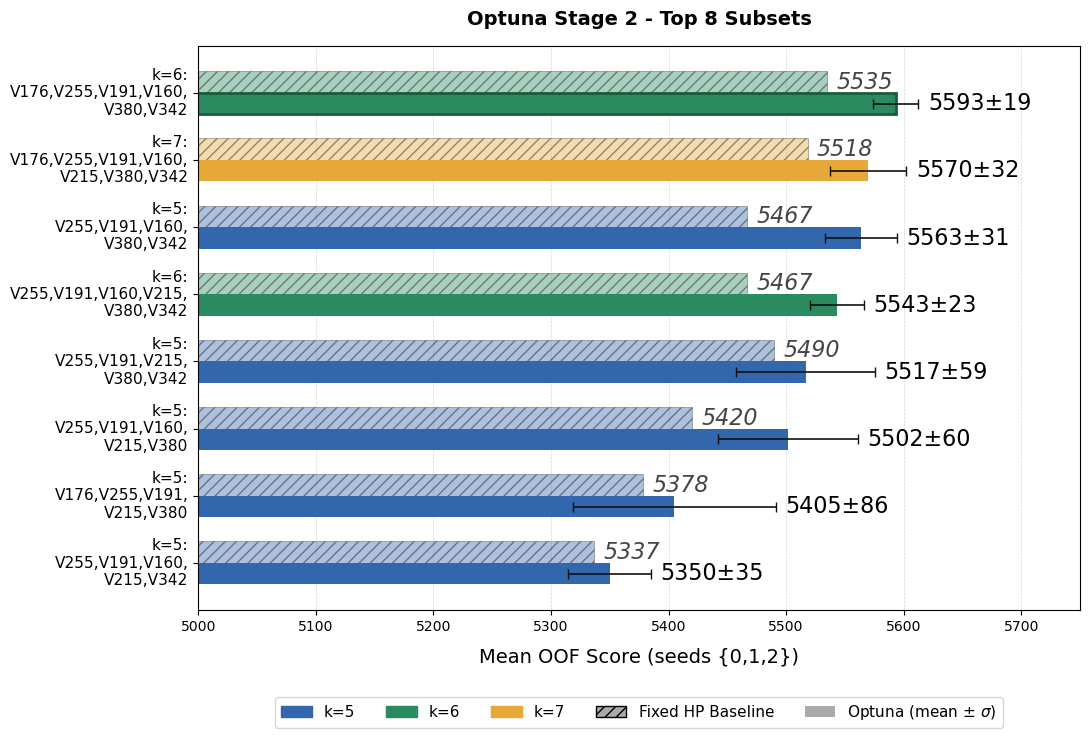

In [41]:
df = pd.read_csv("../results/features_subset_selection/exhaustive_stage2.csv")
df["features"] = df["features"].apply(ast.literal_eval)

CANDIDATES = ["V176", "V255", "V191", "V160", "V215", "V380", "V342"]

def feat_label(feats, k):
    present = [f for f in CANDIDATES if f in set(feats)]

    if len(present) >= 5:
        mid = len(present) // 2 + 1
        row1 = ",".join(present[:mid])
        row2 = ",".join(present[mid:])
        return f"k={k}:\n{row1},\n{row2}"
    else:
        return f"k={k}:\n" + ",".join(present)

labels = [feat_label(r.features, r.k) for _, r in df.iterrows()]
means = df["score"].values
stds = df["std"].values
baselines = df["fixed_baseline"].values
k_vals = df["k"].values

k_colors = {5: "#3266ad", 6: "#2a8a60", 7: "#e8a838"}
colors = [k_colors[k] for k in k_vals]

n = len(df)
y = np.arange(n)
h = 0.32

fig, ax = plt.subplots(figsize=(11, 7.5))

ax.barh(
    y - h / 2,
    baselines,
    height=h,
    color=colors,
    alpha=0.4,
    hatch="///",
    edgecolor="black",
    linewidth=0.5,
)
ax.barh(
    y + h / 2,
    means,
    height=h,
    xerr=stds,
    color=colors,
    error_kw=dict(ecolor="#111", lw=1.2, capsize=3.5),
)

ax.patches[n].set_edgecolor("#1a5c3a")
ax.patches[n].set_linewidth(2.0)

for i, (m, s, b) in enumerate(zip(means, stds, baselines)):
    ax.text(m + s + 8, i + h / 2, f"{m:.0f}±{s:.0f}", va="center", fontsize=16)
    ax.text(
        b + 8,
        i - h / 2,
        f"{b:.0f}",
        va="center",
        fontsize=16,
        color="#444",
        style="italic",
    )

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11.0, va="center")
ax.invert_yaxis()

ax.set_xlim(5000, 5750)

ax.set_xlabel("Mean OOF Score (seeds {0,1,2})", fontsize=14, labelpad=10)
ax.set_title("Optuna Stage 2 - Top 8 Subsets", fontsize=14, pad=15, weight="bold")
ax.grid(axis="x", lw=0.5, alpha=0.5, linestyle="--")
ax.set_axisbelow(True)

k_legend = [
    mpatches.Patch(color=c, label=f"k={k}") for k, c in sorted(k_colors.items())
]
type_legend = [
    mpatches.Patch(
        facecolor="#aaa", hatch="///", edgecolor="black", label="Fixed HP Baseline"
    ),
    mpatches.Patch(facecolor="#aaa", label="Optuna (mean ± $\sigma$)"),
]

ax.legend(
    handles=k_legend + type_legend,
    fontsize=11,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=5,
    frameon=True,
)

plt.tight_layout()
plt.savefig("optuna_stage2_improved.png", dpi=180, bbox_inches="tight")
plt.show()